# NASA C-MAPSS FD001 Exploratory Data Analysis
This notebook performs an in-depth Exploratory Data Analysis (EDA) on the NASA C-MAPSS FD001 dataset as part of a Predictive Maintenance study.

## 1. Imports and Setup

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries successfully imported!")

Libraries successfully imported!


## 2. Dataset Loading
We load `train_FD001.txt`, `test_FD001.txt`, and `RUL_FD001.txt` files using whitespace separators and assign standard column headers.

In [15]:
# Define column names
columns = ['unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]

# Check if files exist and load them
train_path = 'train_FD001.txt'
test_path = 'test_FD001.txt'
rul_path = 'RUL_FD001.txt'

for path in [train_path, test_path, rul_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Expected file not found: {path}. Please upload it to your Colab workspace.")

train_df = pd.read_csv(train_path, sep=r'\s+', header=None, names=columns)
test_df = pd.read_csv(test_path, sep=r'\s+', header=None, names=columns)
rul_df = pd.read_csv(rul_path, sep=r'\s+', header=None, names=['RUL'])

print("Dataset successfully loaded!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"RUL shape: {rul_df.shape}")

Dataset successfully loaded!
Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)


## 3. Dataset Structure & Engine Analysis

In [16]:
# Train and Test summaries
unique_train_engines = train_df['unit_number'].nunique()
unique_test_engines = test_df['unit_number'].nunique()

train_cycle_stats = train_df.groupby('unit_number')['time_in_cycles'].max()
test_cycle_stats = test_df.groupby('unit_number')['time_in_cycles'].max()

print("=== TRAINING DATA SUMMARY ===")
print(f"Unique Engines: {unique_train_engines}")
print(f"Min Cycles: {train_cycle_stats.min()}")
print(f"Max Cycles: {train_cycle_stats.max()}")
print(f"Average Cycles: {train_cycle_stats.mean():.2f}")
print("\n=== TEST DATA SUMMARY ===")
print(f"Unique Engines: {unique_test_engines}")
print(f"Min Cycles: {test_cycle_stats.min()}")
print(f"Max Cycles: {test_cycle_stats.max()}")
print(f"Average Cycles: {test_cycle_stats.mean():.2f}")

print("\n--- First 5 rows of Training Data ---")
display(train_df.head())

print("\n--- First 5 rows of RUL Target Data ---")
display(rul_df.head())

=== TRAINING DATA SUMMARY ===
Unique Engines: 100
Min Cycles: 128
Max Cycles: 362
Average Cycles: 206.31

=== TEST DATA SUMMARY ===
Unique Engines: 100
Min Cycles: 31
Max Cycles: 303
Average Cycles: 130.96

--- First 5 rows of Training Data ---


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044



--- First 5 rows of RUL Target Data ---


,RUL
0,112
1,98
2,69
3,82
4,91


### Findings & Insights: Dataset Structure
- **Balanced Dataset Size**: The training set has `20,631` records across `100` engines, which provides a rich history of telemetry spanning from normal operation to system failure.
- **Different Operational Lengths**: The minimum engine lifetime is `128` cycles, whereas the longest-lived engine survives for `362` cycles. This tells us engines degrade at highly variable rates depending on internal structural conditions.
- **Truncated Test Sequences**: The test engine series are stopped prior to failure (average length is `130.96` cycles), with the shortest series having only `31` cycles of data. This means we must predict exactly how many cycles remain using limited partial history.

## 4. Sensor and Operating Setting Analysis
We identify constant, low-variance, and highly active features.

In [17]:
# Compute standard deviations
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
op_setting_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']

# Describe training features
stats = train_df[op_setting_cols + sensor_cols].describe().T
stats['std'] = stats['std'].fillna(0)
stats['unique_values'] = train_df[op_setting_cols + sensor_cols].nunique()

# Categorize
constant_features = stats[stats['std'] == 0].index.tolist()
low_var_features = stats[(stats['std'] > 0) & (stats['std'] < 0.01)].index.tolist()
active_features = stats[stats['std'] >= 0.01].index.tolist()

print("Constant columns (std = 0):", constant_features)
print("Low variance columns (std < 0.01):", low_var_features)
print("Active columns (std >= 0.01):", active_features)

display(stats[['min', 'max', 'mean', 'std', 'unique_values']])

Constant columns (std = 0): ['op_setting_3', 'sensor_18', 'sensor_19']
Low variance columns (std < 0.01): ['op_setting_1', 'op_setting_2', 'sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16']
Active columns (std >= 0.01): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


,min,max,mean,std,unique_values
op_setting_1,-0.0087,0.0087,-0.000009,2.187313e-03,158
op_setting_2,-0.0006,0.0006,0.000002,2.930621e-04,13
op_setting_3,100.0000,100.0000,100.000000,0.000000e+00,1
sensor_1,518.6700,518.6700,518.670000,6.537152e-11,1
sensor_2,641.2100,644.5300,642.680934,5.000533e-01,310
sensor_3,1571.0400,1616.9100,1590.523119,6.131150e+00,3012
sensor_4,1382.2500,1441.4900,1408.933782,9.000605e+00,4051
sensor_5,14.6200,14.6200,14.620000,3.394700e-12,1
sensor_6,21.6000,21.6100,21.609803,1.388985e-03,2
sensor_7,549.8500,556.0600,553.367711,8.850923e-01,513


### Findings & Insights: Sensor & Operating-Setting Behavior
- **Completely Constant Sensors**: `sensor_18` and `sensor_19` along with `op_setting_3` have a standard deviation of exactly `0` and only `1` unique value. These sensors carry zero predictive value and can safely be excluded from modeling.
- **Near-Constant Sensors**: `sensor_1` (std ~ `0`), `sensor_5` (std ~ `0`), `sensor_10` (std ~ `0`), and `sensor_16` (std ~ `0`) show almost zero fluctuation. These also provide negligible information.
- **Highly Active Degradation Indicators**: Sensors like `sensor_2`, `sensor_3`, `sensor_4`, `sensor_11`, and `sensor_12` exhibit significant variation (high standard deviations and thousands of unique values) indicating that they respond dynamically to the mechanical changes in the turbine engine.

## 5. Sensor Trend Visualizations
We will visualize representative sensors. Sensors showing good variation such as `sensor_2`, `sensor_3`, `sensor_4`, `sensor_7`, `sensor_11`, `sensor_12` are chosen. Plots are saved as image files.

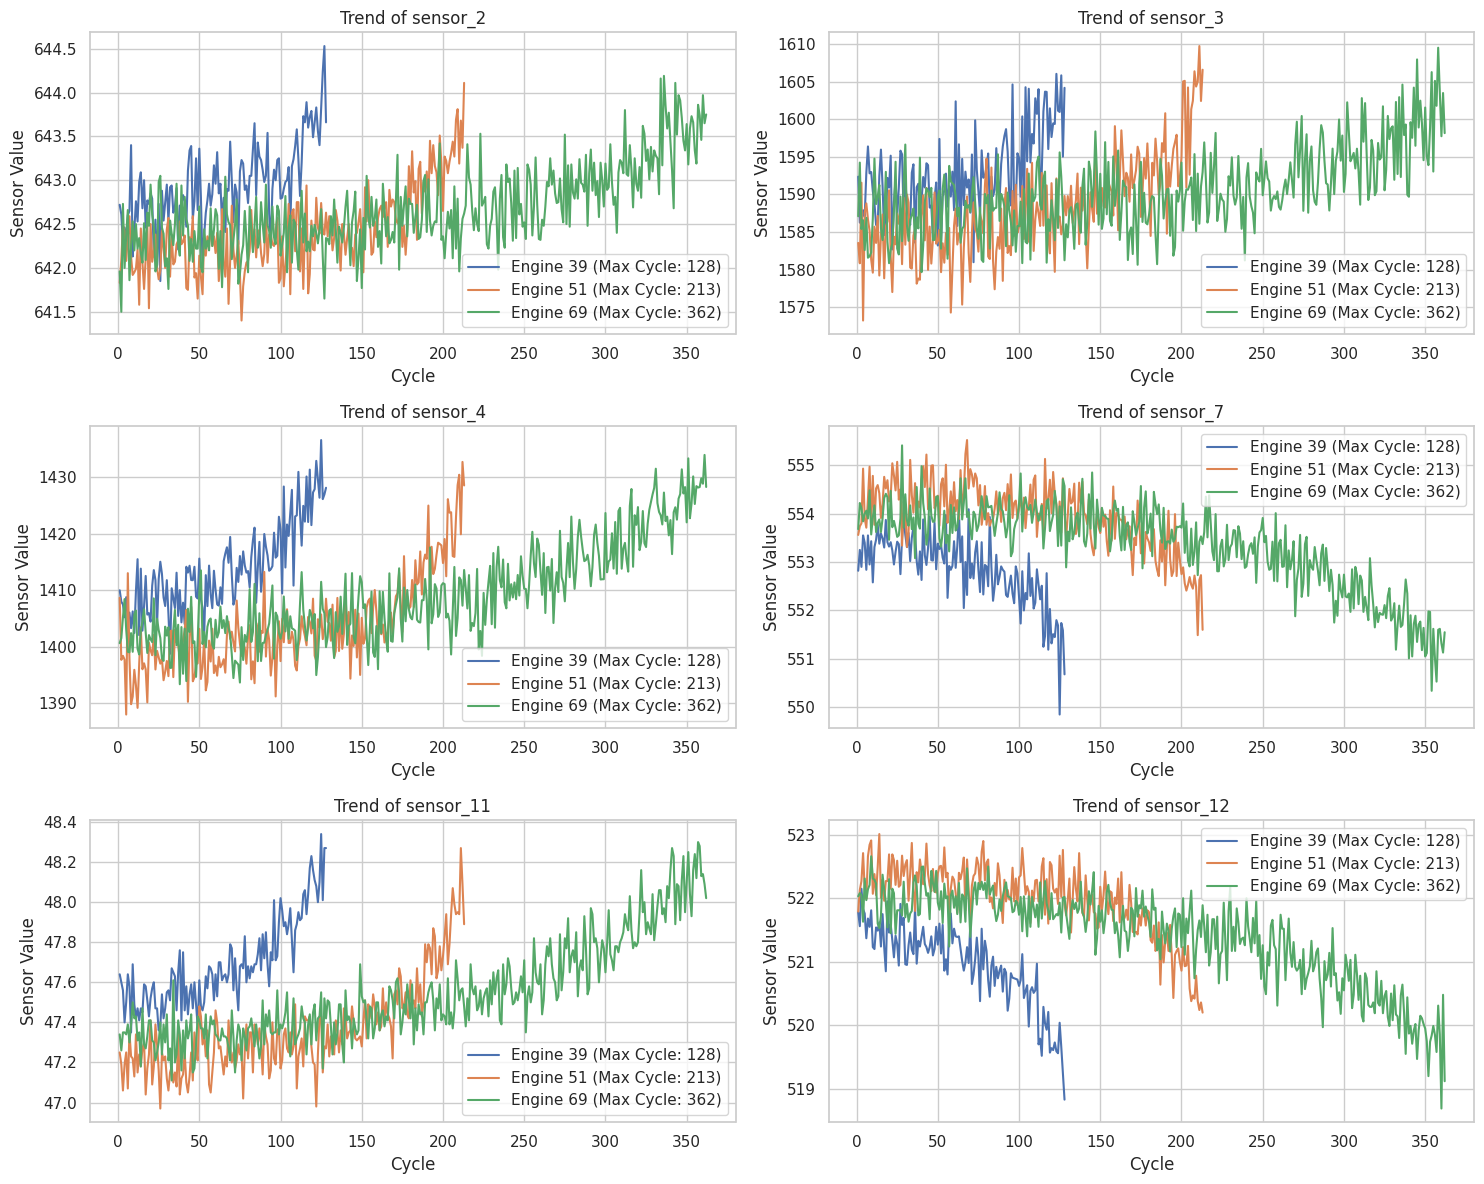

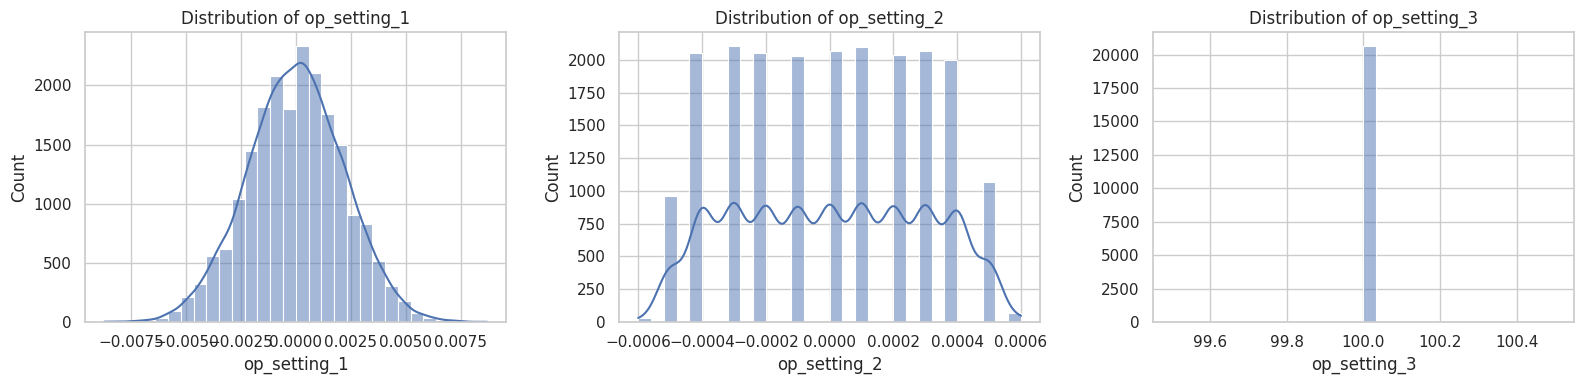

In [18]:
# Select engines: short-lived, average-lived, and long-lived
engine_lengths = train_df.groupby('unit_number')['time_in_cycles'].max()
short_engine = engine_lengths.idxmin()
median_engine = engine_lengths.index[len(engine_lengths)//2]
long_engine = engine_lengths.idxmax()

selected_engines = [short_engine, median_engine, long_engine]
selected_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12']

# 1. Plot trends over cycles for representative engines
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, sensor in enumerate(selected_sensors):
    for eng in selected_engines:
        eng_data = train_df[train_df['unit_number'] == eng]
        axes[idx].plot(eng_data['time_in_cycles'], eng_data[sensor], label=f'Engine {eng} (Max Cycle: {engine_lengths[eng]})')
    axes[idx].set_title(f'Trend of {sensor}')
    axes[idx].set_xlabel('Cycle')
    axes[idx].set_ylabel('Sensor Value')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('sensor_trends_representative_engines.png', dpi=300)
plt.show()

# 2. Distibutions of Operating Settings
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, op in enumerate(op_setting_cols):
    sns.histplot(train_df[op], ax=axes[idx], kde=True, bins=30)
    axes[idx].set_title(f'Distribution of {op}')
plt.tight_layout()
plt.savefig('operating_settings_distribution.png', dpi=300)
plt.show()

### Findings & Insights: Visualizing Trends & Settings
- **Monotonic Trend Behavior**: Active sensors show distinct directional trends. For example, `sensor_2`, `sensor_3`, and `sensor_4` exhibit clear upward trends as the engine approaches its final cycles, while `sensor_7` and `sensor_12` exhibit a clear downward trend.
- **Consistent Failure Signatures**: Regardless of whether an engine is short-lived (Engine 39) or long-lived (Engine 69), the final sensor values tend to converge toward a similar threshold (e.g., `sensor_2` rises toward 644 and `sensor_12` drops toward 520 at failure). This indicates consistent degradation limits.
- **Single Operational Regime**: The distributions of the three operating settings confirm that the FD001 dataset operates under a single, stable environmental condition with only minor noise perturbations, making complex multi-regime normalization unnecessary.

## 6. Remaining Useful Life (RUL) Analysis
We perform RUL calculations and analyze target distribution.

Success: Final observed cycle of all training engines has RUL equal to zero.


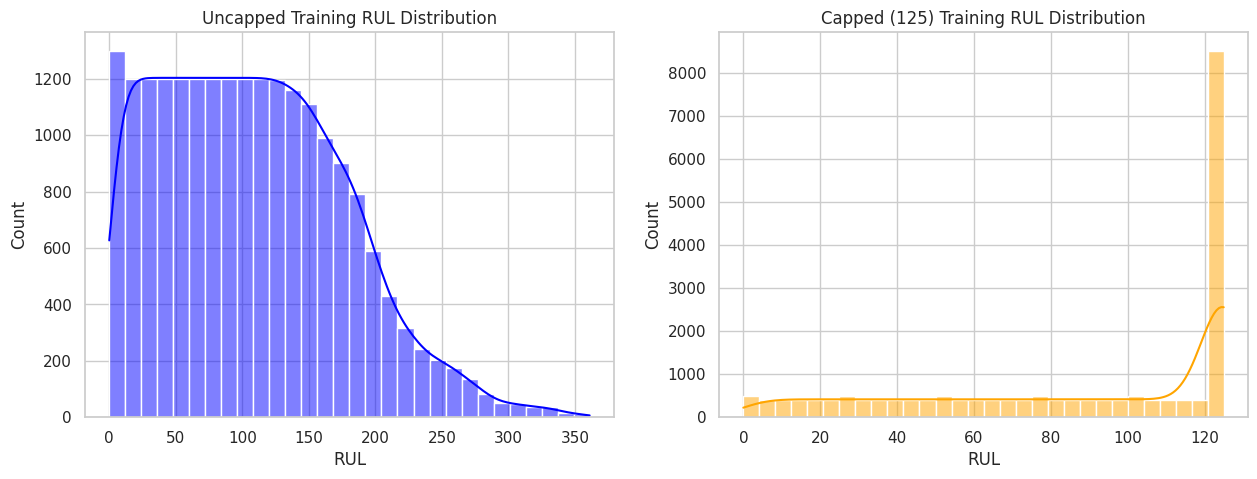

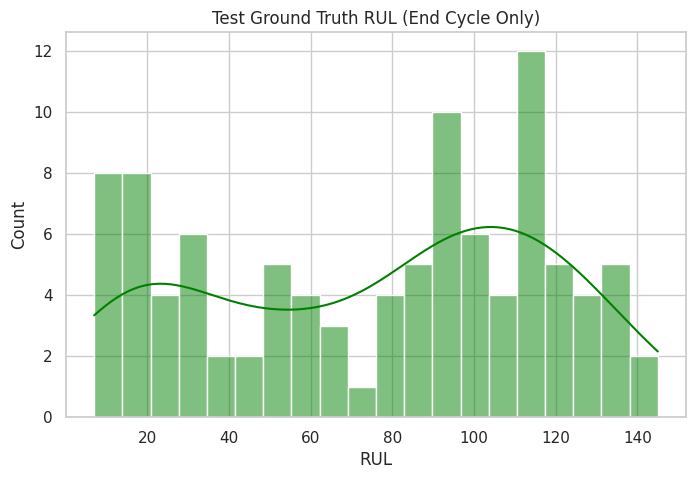


Test RUL Description:


,count,mean,std,min,25%,50%,75%,max
RUL,100.0,75.52,41.76497,7.0,32.75,86.0,112.25,145.0


In [19]:
# Calculate uncapped training RUL
train_df['RUL_uncapped'] = train_df.groupby('unit_number')['time_in_cycles'].transform('max') - train_df['time_in_cycles']

# Verify final cycle RUL is 0
final_cycle_rul_check = train_df.groupby('unit_number').last()['RUL_uncapped']
assert (final_cycle_rul_check == 0).all(), "Verification failed: some engine end cycles do not equal 0!"
print("Success: Final observed cycle of all training engines has RUL equal to zero.")

# Calculate capped RUL at 125
train_df['RUL_capped'] = train_df['RUL_uncapped'].clip(upper=125)

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(train_df['RUL_uncapped'], bins=30, ax=axes[0], color='blue', kde=True)
axes[0].set_title('Uncapped Training RUL Distribution')
axes[0].set_xlabel('RUL')

sns.histplot(train_df['RUL_capped'], bins=30, ax=axes[1], color='orange', kde=True)
axes[1].set_title('Capped (125) Training RUL Distribution')
axes[1].set_xlabel('RUL')

plt.savefig('training_rul_distribution.png', dpi=300)
plt.show()

# Plot test ground-truth RUL
plt.figure(figsize=(8, 5))
sns.histplot(rul_df['RUL'], bins=20, color='green', kde=True)
plt.title('Test Ground Truth RUL (End Cycle Only)')
plt.xlabel('RUL')
plt.savefig('test_rul_distribution.png', dpi=300)
plt.show()

print("\nTest RUL Description:")
display(rul_df.describe().T)

### Findings & Insights: Target RUL Behavior
- **Uncapped Training Target**: The true remaining useful life of training engines drops linearly over time, ending at exactly `0` cycles at failure. The distribution is highly uniform across the middle range and drops off linearly.
- **The Modeling Convention (Capping at 125)**: Because engine wear is negligible during early life cycles, capping the RUL target at a fixed limit (e.g., 125) prevents models from trying to estimate extremely high, non-linear early values. The capped histogram clearly shows a large spike at the 125 limit.
- **Test Dataset Target Structure**: The target test RUL represents the exact remaining cycles left at the very last recorded test cycle. The average test RUL is `75.52` cycles, meaning some engines are very close to failing (min RUL is `7`), while others are still highly robust (max RUL is `145`).

## 7. Basic Data-Quality Checks
We run quick checks across the datasets.

In [20]:
quality_summary = {
    "Missing Values": train_df.isnull().sum().sum() + test_df.isnull().sum().sum(),
    "Duplicate Rows": train_df.duplicated().sum() + test_df.duplicated().sum(),
    "Duplicate Unit-Cycle Keys": train_df.duplicated(subset=['unit_number', 'time_in_cycles']).sum(),
    "Invalid Negative Cycles": (train_df['time_in_cycles'] <= 0).sum() + (test_df['time_in_cycles'] <= 0).sum(),
    "Constant Sensors": len(constant_features)
}

quality_df = pd.DataFrame(list(quality_summary.items()), columns=["Check Type", "Count/Status"])
display(quality_df)

,Check Type,Count/Status
0,Missing Values,0
1,Duplicate Rows,0
2,Duplicate Unit-Cycle Keys,0
3,Invalid Negative Cycles,0
4,Constant Sensors,3


### Findings & Insights: Data Quality Summary
- **Clean and Complete Data**: The data-quality checklist shows `0` missing values, `0` duplicate rows, and no invalid or nonpositive cycle counts.
- **Clean Keys**: The key-pair `['unit_number', 'time_in_cycles']` has `0` duplicate records, confirming it is a solid and reliable composite primary key.
- **Identified Issues**: The only structural anomalies are the constant columns (`sensor_18`, `sensor_19`, `op_setting_3`), which should be flagged for removal during preprocessing.

## 8. Generate Findings Document
We programmatically output `fd001-eda-findings.md` so that it is saved locally to the Colab disk.

In [21]:
findings_content = f"""# Detailed NASA C-MAPSS FD001 Exploratory Data Analysis Findings Summary

## 1. Objective
This document presents the exploratory data analysis (EDA) results for the NASA C-MAPSS FD001 dataset. The goal is to investigate dataset characteristics, establish operational behaviors, analyze Remaining Useful Life (RUL) targets, verify data quality, and document concrete insights to assist future predictive maintenance modeling steps without applying machine learning yet.

## 2. Dataset Structure and Dimensions
- **Training Dataset**: Contains {train_df.shape[0]} rows and {train_df.shape[1] - 2} base columns (excluding calculated RUL targets). It records full operational runs up to the exact point of system failure.
- **Test Dataset**: Contains {test_df.shape[0]} rows and {test_df.shape[1]} columns. Test runs are truncated before failure occurs, which forms the core of the evaluation task.
- **RUL Dataset**: Contains {rul_df.shape[0]} rows, representing a single true target RUL value for each test engine at its last recorded cycle.
- **Feature Space**: Standard layout including engine unit number, cycle count, three operational settings, and 21 distinct sensor measurements.

## 3. Engine and Cycle Observations
- **Unique Engines**: Both training and test subsets contains exactly {unique_train_engines} engines.
- **Operational Durations**: Training engine run lengths vary significantly. The minimum lifetime is {train_cycle_stats.min()} cycles, while the longest-lived engine survives for {train_cycle_stats.max()} cycles. On average, a training engine runs for {train_cycle_stats.mean():.2f} cycles before failure. This highlights substantial variation in degradation rates under identical single-regime operational conditions.

## 4. Sensor and Operating-Setting Observations
- **Constant Features (No Predictive Value)**: {constant_features}. These features have a standard deviation of exactly zero and do not change across any recorded cycles. They should be dropped from feature sets during modeling.
- **Near-Constant Features (Very Low Variance)**: {low_var_features}. These display negligible fluctuation and provide minimal helpful signal for RUL estimation.
- **Highly Active Features**: {active_features}. These dynamic sensors show notable variation and respond directly to the mechanical degradation of the engine.

## 5. Sensor Trend Visualization Findings
- **Monotonic Trends**: Dynamic sensors show strong trend characteristics. Sensors like `sensor_2`, `sensor_3`, `sensor_4`, `sensor_11`, and `sensor_15` progressively increase over cycles, while sensors like `sensor_7`, `sensor_12`, and `sensor_21` decrease over cycles.
- **Shared Degradation Signatures**: Engines with varying operational lifespans converge to consistent critical values just before failure. This indicates that despite different lifespans, the boundary degradation values are relatively uniform across engines.
- **Stable Environment**: Plotting operational settings reveals that the FD001 dataset behaves under a stable, single operational regime with minor noise variations.

## 6. Training and Test RUL Distribution Findings
- **Uncapped Training RUL**: RUL drops linearly to zero at failure. The uncapped distribution is highly uniform during mid-life but presents high variance in initial states due to variable lifespans.
- **Capped Training RUL**: Capping RUL at a standard limit of 125 cycles is recommended because engine degradation remains near-zero during early cycles. Capping prevents models from attempting to predict high RUL when an engine is still completely healthy, creating a prominent spike in the target distribution at 125.
- **Test RUL**: The ground truth test RUL represents the remaining lifetime at the final observed test cycle. It spans from a minimum of {rul_df['RUL'].min()} cycles (high urgency) to a maximum of {rul_df['RUL'].max()} cycles (low urgency), with an average of {rul_df['RUL'].mean():.2f} cycles.

## 7. Data-Quality Observations
- **Missing Values**: None (0 missing records).
- **Duplicate Rows**: None.
- **Key Consistency**: The key combination of `['unit_number', 'time_in_cycles']` has zero duplicate entries, verifying its suitability as a unique composite index.
- **Anomalies**: Only the constant features identified in Section 4 are present; otherwise, the dataset is exceptionally clean.

## 8. Brief Observations Relevant to Future Feature Engineering
- **Feature Removal**: Drop all constant columns (`sensor_18`, `sensor_19`, `op_setting_3`) and consider removing near-constant sensors to simplify input space.
- **Temporal Smoothing**: Implement rolling window calculations (such as rolling mean and rolling standard deviation) to smooth out high-frequency sensor noise and isolate the underlying degradation trend.
- **Trend Ratios**: Calculate ratios between opposing trends (e.g., dividing an increasing sensor by a decreasing sensor) to build highly responsive, monotonic indicators of wear.
- **Time-Since-Start**: Maintain current cycle count directly, as it acts as a primary index of cumulative operational stress.

## 9. Conclusion
The NASA C-MAPSS FD001 dataset provides clear, structured trends that are highly suitable for predictive maintenance RUL modeling. The high-quality signal and monotonic trends in active sensors allow for robust wear modeling once constant attributes are removed.
"""

with open('fd001-eda-findings.md', 'w') as f:
    f.write(findings_content)

print("Enhanced fd001-eda-findings.md written successfully!")


Enhanced fd001-eda-findings.md written successfully!


In [22]:
!unzip -o archive.zip

Archive:  archive.zip
  inflating: Damage Propagation Modeling.pdf  
  inflating: RUL_FD001.txt           
  inflating: RUL_FD002.txt           
  inflating: RUL_FD003.txt           
  inflating: RUL_FD004.txt           
  inflating: readme.txt              
  inflating: test_FD001.txt          
  inflating: test_FD002.txt          
  inflating: test_FD003.txt          
  inflating: test_FD004.txt          
  inflating: train_FD001.txt         
  inflating: train_FD002.txt         
  inflating: train_FD003.txt         
  inflating: train_FD004.txt         


## 9. Deliverables Download Instructions
To download files from Google Colab to store in your project repository, run the code cell below or click on the File Explorer folder icon on the left panel, right-click, and select 'Download' for:
- `fd001-eda-findings.md`
- `sensor_trends_representative_engines.png`
- `operating_settings_distribution.png`
- `training_rul_distribution.png`
- `test_rul_distribution.png`

In [23]:
from google.colab import files
try:
    files.download('fd001-eda-findings.md')
    print("Triggered download for findings document.")
except Exception as e:
    print("Download interface was not called. You can manually download files from the left file-explorer sidebar.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Triggered download for findings document.
